<a href="https://colab.research.google.com/github/panzehui0206/AI4S-365days/blob/main/%E7%AC%AC%E4%BA%8C%E7%AB%A0%20%E7%94%9F%E5%91%BD%E7%A7%91%E5%AD%A6%E7%9A%84%E2%80%9C%E8%87%AA%E7%84%B6%E8%AF%AD%E8%A8%80%E2%80%9D%E2%80%94%E2%80%94%E5%BA%8F%E5%88%97%E5%A4%84%E7%90%86/Note2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

开始学习吧！

In [1]:
# =============================================
# Cell 1：导入库 + 配置 Entrez 邮箱
# =============================================
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install biopython -q

# SwissProt 是 Biopython 解析 UniProt 文件的模块
from Bio import Entrez, SeqIO, SwissProt
import matplotlib.pyplot as plt
import pandas as pd

# Entrez 是 NCBI 的检索系统，涵盖 PubMed、GenBank、SNP 等数十个数据库。
# NCBI 要求每个请求都带有用户邮箱，用于追踪异常流量
Entrez.email = "panzehui0206@163.com"

print("✅ 环境准备完毕！")
print(f"📧 Entrez 邮箱已设置为: {Entrez.email}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.2 MB/s eta 0:00:00
✅ 环境准备完毕！
📧 Entrez 邮箱已设置为: panzehui0206@163.com


In [2]:
# =============================================
# Cell 2：用 Entrez 搜索并下载 GenBank 记录
# =============================================
# 搜索人类 TP53 基因的 RefSeq 完整记录
search_term = "TP53[Gene] AND Homo sapiens[Organism] AND refseq[filter]"
handle = Entrez.esearch(db="nucleotide", term=search_term, retmax=5)
record = Entrez.read(handle)
handle.close()

print(f"🔍 搜索词: {search_term}")
print(f"📋 找到 {record['Count']} 条记录，显示前 {len(record['IdList'])} 条 ID:")
for i, gid in enumerate(record['IdList']):
    print(f"  {i+1}. {gid}")

# 选择第一条（通常是参考序列）
target_id = record['IdList'][0]

# 用 efetch 根据 ID 下载完整记录，rettype="gb" 指定 GenBank 格式
handle = Entrez.efetch(db="nucleotide", id=target_id, rettype="gb", retmode="text")
gb_record = SeqIO.read(handle, "genbank")
handle.close()

print(f"\n✅ 已下载 GenBank 记录: {gb_record.id}")
print(f"📄 描述: {gb_record.description}")
print(f"📏 序列长度: {len(gb_record.seq):,} bp")

🔍 搜索词: TP53[Gene] AND Homo sapiens[Organism] AND refseq[filter]
📋 找到 30 条记录，显示前 5 条 ID:
  1. 383209646
  2. 2194972897
  3. 568815581
  4. 2246031203
  5. 1894803104

✅ 已下载 GenBank 记录: NG_017013.2
📄 描述: Homo sapiens tumor protein p53 (TP53), RefSeqGene (LRG_321) on chromosome 17
📏 序列长度: 32,772 bp


In [6]:
# =============================================
# Cell 3：提取特征表中的 CDS 区域
# =============================================
# GenBank 文件的特征表（feature table）是核心
# 它以坐标方式标注了基因的各个功能区域（CDS、mRNA、exon、intron、promoter 等）
cds_list = []
for feature in gb_record.features:
    if feature.type == "CDS":
        # 提取位置信息
        location = str(feature.location)

        # 提取蛋白 ID 和产物名称（可能缺失）
        # qualifiers 是一个字典，存储该特征的附加信息
        protein_id = feature.qualifiers.get("protein_id", ["N/A"])[0]
        product = feature.qualifiers.get("product", ["N/A"])[0]

        # 提取翻译产物（如果 GenBank 包含）
        translation = feature.qualifiers.get("translation", [""])[0]

        cds_list.append({
            "location": location,
            "protein_id": protein_id,
            "product": product,
            "translation_length": len(translation)
        })
        print(f"   CDS: {location}")
        print(f"   蛋白ID: {protein_id}")
        print(f"   产物: {product[:50]}..." if len(product)>50 else f"   产物: {product}")
        if translation:
            print(f"   翻译长度: {len(translation)} aa")
        print()

# 转为 DataFrame 便于查看
df_cds = pd.DataFrame(cds_list)
print(f"📊 共找到 {len(df_cds)} 个 CDS 区域")
df_cds.head()

   CDS: join{[3471:3902](-), [3228:3327](-), [<2849:2961](-)}
   蛋白ID: NP_060551.2
   产物: telomerase Cajal body protein 1
   翻译长度: 548 aa

   CDS: join{[3471:3902](-), [3228:3327](-), [<2849:2961](-)}
   蛋白ID: NP_001137462.1
   产物: telomerase Cajal body protein 1
   翻译长度: 548 aa

   CDS: join{[3471:3902](-), [3228:3327](-), [<2849:2961](-)}
   蛋白ID: NP_001137463.1
   产物: telomerase Cajal body protein 1
   翻译长度: 548 aa

   CDS: join{[3471:3902](-), [3228:3327](-), [<2849:2961](-)}
   蛋白ID: NP_001137464.1
   产物: telomerase Cajal body protein 1
   翻译长度: 548 aa

   CDS: join{[15956:16030](+), [16147:16169](+), [16278:16557](+), [17314:17498](+), [17579:17692](+), [18260:18370](+), [18713:18850](+), [18942:19016](+), [21835:21942](+), [22860:22942](+)}
   蛋白ID: NP_000537.3
   产物: cellular tumor antigen p53 isoform a
   翻译长度: 393 aa

   CDS: join{[15956:16030](+), [16147:16169](+), [16278:16557](+), [17314:17498](+), [17579:17692](+), [18260:18370](+), [18713:18850](+), [18942:19016](+), [21

,location,protein_id,product,translation_length
0,"join{[3471:3902](-), [3228:3327](-), [<2849:29...",NP_060551.2,telomerase Cajal body protein 1,548
1,"join{[3471:3902](-), [3228:3327](-), [<2849:29...",NP_001137462.1,telomerase Cajal body protein 1,548
2,"join{[3471:3902](-), [3228:3327](-), [<2849:29...",NP_001137463.1,telomerase Cajal body protein 1,548
3,"join{[3471:3902](-), [3228:3327](-), [<2849:29...",NP_001137464.1,telomerase Cajal body protein 1,548
4,"join{[15956:16030](+), [16147:16169](+), [1627...",NP_000537.3,cellular tumor antigen p53 isoform a,393


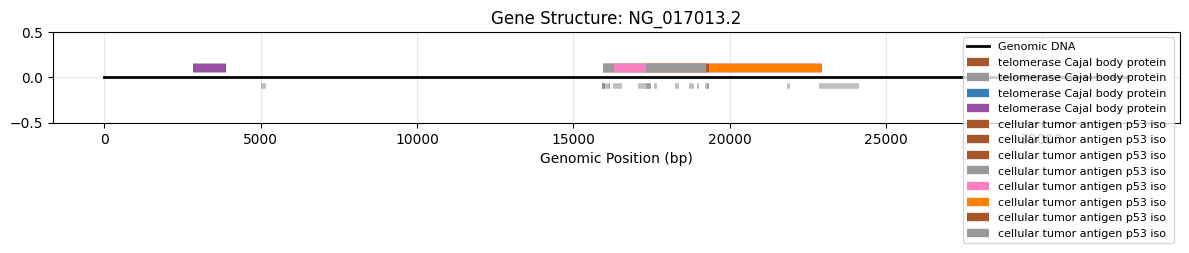

In [7]:
# =============================================
# Cell 4：可视化基因结构
# =============================================
# 提取所有外显子和 CDS 坐标（注意：GenBank 中 exon 特征可能不完整，我们用 CDS 近似）
fig, ax = plt.subplots(figsize=(12, 2))

# 画全长序列横线
seq_len = len(gb_record.seq)
ax.plot([0, seq_len], [0, 0], color='black', linewidth=2, label='Genomic DNA')

# 遍历特征，画出 CDS 和外显子
colors = plt.cm.Set1.colors
for i, feature in enumerate(gb_record.features):
    if feature.type == "CDS":
        start = int(feature.location.start)
        end = int(feature.location.end)
        ax.plot([start, end], [0.1, 0.1], linewidth=6, solid_capstyle='butt',
                color=colors[i % len(colors)], label=feature.qualifiers.get("product", [""])[0][:30])
    if feature.type == "exon":
        start = int(feature.location.start)
        end = int(feature.location.end)
        ax.plot([start, end], [-0.1, -0.1], linewidth=4, solid_capstyle='butt', color='grey', alpha=0.5)

ax.set_xlabel('Genomic Position (bp)')
ax.set_title(f'Gene Structure: {gb_record.id}')
ax.set_ylim(-0.5, 0.5)
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

底部的黑色横线是完整的**基因组DNA序列**。

上方较粗的彩色条块是 **CDS** 。

下方较细的灰色条块是 **Exon** 。

这张图可以帮助设计PCR引物，CDS分布在哪些位置？需要扩增哪个片段才能拿到全长编码区？
帮助可变剪接分析，这个基因有多个CDS，它们在基因组上的外显子组成有何不同？
帮助进行突变定位，患者的一个点突变落在第几号外显子上？时CDS内部还是UTR？
还可以结合多序列对比，判断进化保守性。



In [8]:
# =============================================
# Cell 5：从 UniProt 获取蛋白功能注释
# =============================================
# 从第一条 CDS 提取 protein_id（通常可映射到 UniProt）
if len(cds_list) > 0 and cds_list[0]["protein_id"] != "N/A":
    prot_id = cds_list[0]["protein_id"]
    print(f"🔗 尝试用 protein_id '{prot_id}' 搜索 UniProt...")

    # 用 Entrez 从 UniProt 数据库搜索（NCBI 的 protein 库与 UniProt 有交叉）
    handle = Entrez.esearch(db="protein", term=f"{prot_id}[Accession]")
    record = Entrez.read(handle)
    handle.close()

    if record['IdList']:
        # 下载 UniProt 格式（SwissProt）
        handle = Entrez.efetch(db="protein", id=record['IdList'][0], rettype="gb", retmode="text")
        prot_record = SeqIO.read(handle, "genbank")
        handle.close()

        print(f"\n📄 UniProt 记录: {prot_record.id}")
        print(f"📝 描述: {prot_record.description}")

        # 提取 GO 注释和结构域（从特征表）
        go_terms = []
        domains = []
        # 遍历蛋白质记录的特征表
        for feature in prot_record.features:
            # 提取结构域
            if feature.type == "Region" and "region_name" in feature.qualifiers:
                domains.append(feature.qualifiers["region_name"][0])
            # 提取 GO 功能注释
            if "GO_component" in feature.qualifiers or "GO_function" in feature.qualifiers or "GO_process" in feature.qualifiers:
                go_terms.extend(feature.qualifiers.get("GO_function", []))

        print(f"\n🧩 结构域: {domains[:5] if domains else '未标注'}")
        print(f"🏷️ GO 功能注释 (前3条): {go_terms[:3] if go_terms else '未标注'}")
    else:
        print("⚠️ 未在 NCBI protein 库找到对应记录")
else:
    print("⚠️ 未找到有效的 protein_id，跳过 UniProt 关联")

🔗 尝试用 protein_id 'NP_060551.2' 搜索 UniProt...

📄 UniProt 记录: NP_060551.2
📝 描述: telomerase Cajal body protein 1 [Homo sapiens]

🧩 结构域: ['Disordered. /evidence=ECO:0000256|SAM:MobiDB-lite', 'WD 1. /evidence=ECO:0000255', 'WD40 repeat', 'WD40', 'WD 2. /evidence=ECO:0000255']
🏷️ GO 功能注释 (前3条): 未标注


这段代码从 **GenBank** 中提取的**蛋白质 ID** 出发，到 **UniProt** 数据库中获取该蛋白质的功能注释（结构域、GO 术语等），这是从“这条序列存在”到“这条序列干什么”的关键一步。

结构域能告诉我们这个蛋白有哪些功能模块，它如何与DNA/其它蛋白互作。
GO分子功能能告诉我们它在分子层面具体做什么。
GO生物过程告诉我们它能参与哪些生物学通路。
GO细胞组分告诉我们它在细胞中的什么位置发挥作用。
这些注释在建模任务中发挥重要作用，是监督学习的标签来源。

In [9]:
# =============================================
# Cell 6：批量下载并保存 CDS 序列（FASTA）
# =============================================
# 任务：下载 TP53、BRCA1、MYC 三个基因的 CDS 序列，保存为 FASTA
genes = ["TP53", "BRCA1", "MYC"]
output_file = "three_genes_cds.fasta"

with open(output_file, "w") as out_f:
    for gene in genes:
        print(f"🔍 处理 {gene}...")
        # 搜索基因的 RefSeq mRNA
        handle = Entrez.esearch(db="nucleotide", term=f"{gene}[Gene] AND Homo sapiens[Organism] AND mRNA[filter] AND refseq[filter]", retmax=1)
        record = Entrez.read(handle)
        handle.close()

        if record['IdList']:
            gid = record['IdList'][0]
            # 下载 GenBank 格式
            handle = Entrez.efetch(db="nucleotide", id=gid, rettype="gb", retmode="text")
            gb = SeqIO.read(handle, "genbank")
            handle.close()

            # 提取 CDS 特征并写入 FASTA
            for feature in gb.features:
                if feature.type == "CDS":
                    # 提取翻译产物作为蛋白序列
                    if "translation" in feature.qualifiers:
                        seq = feature.qualifiers["translation"][0]
                        out_f.write(f">{gene}_{feature.qualifiers.get('protein_id', [''])[0]}\n")
                        # 每行 60 个氨基酸换行
                        for i in range(0, len(seq), 60):
                            out_f.write(seq[i:i+60] + "\n")
                        print(f"  ✅ 已写入 {gene} CDS")
                        break
        else:
            print(f"  ❌ 未找到 {gene}")

print(f"\n💾 序列已保存至: {output_file}")

# 验证保存的文件
!head -n 10 {output_file}

🔍 处理 TP53...
  ✅ 已写入 TP53 CDS
🔍 处理 BRCA1...
  ✅ 已写入 BRCA1 CDS
🔍 处理 MYC...
  ✅ 已写入 MYC CDS

💾 序列已保存至: three_genes_cds.fasta
>TP53_NP_001119589.1
MFCQLAKTCPVQLWVDSTPPPGTRVRAMAIYKQSQHMTEVVRRCPHHERCSDSDGLAPPQ
HLIRVEGNLRVEYLDDRNTFRHSVVVPYEPPEVGSDCTTIHYNYMCNSSCMGGMNRRPIL
TIITLEDSSGNLLGRNSFEVRVCACPGRDRRTEEENLRKKGEPHHELPPGSTKRALPNNT
SSSPQPKKKPLDGEYFTLQMLLDLRWCYFLINSS
>BRCA1_NP_001395396.1
MLKLLNQKKGPSQCPLCKNDITKRSLQESTRFSQLVEELLKIICAFQLDTGLEYANSYNF
AKKENNSPEHLKDEVSIIQSMGYRNRAKRLLQSEPENPSLQETSLSVQLSNLGTVRTLRT
KQRIQPQKTSVYIELGSDSSEDTVNKATYCSVGDQELLQITPQGTRDEISLDSAKKAACE
FSETDVTNTEHHQPSNNDLNTTEKRAAERHPEKYQGEAASGCESETSVSEDCSGLSSQSD


这段代码是一个生产级脚本的雏形：输入**基因名**，输出高质量蛋白质 **FASTA**，它融合了 **NCBI** **检索语法、GenBank** 特征表解析、以及标准 **FASTA** 文件写入。

今天学了什么呢？

✅ 配置 Entrez API，理解 NCBI 查询语法。

✅ 用 esearch + efetch 在线下载 TP53 基因的 GenBank 记录。

✅ 解析特征表，提取所有 CDS 的坐标、蛋白 ID 和翻译产物。

✅ 绘制基因结构示意图，直观区分编码区与内含子。

✅ 关联 UniProt 获取功能注释（结构域、GO 术语）。

✅ 批量下载多个基因的蛋白序列，保存为 FASTA。